# Modelo de machine learning para la predicción de precios de automóviles usados en la aplicación Rusty Bargain

# Hola &#x1F600;

Soy **Hesus Garcia**, revisor de código de Practicum, y voy a examinar el proyecto que has desarrollado recientemente. Si encuentro algún error, te lo señalaré para que lo corrijas, ya que mi objetivo es ayudarte a prepararte para un ambiente de trabajo real, donde el líder de tu equipo actuaría de la misma manera. Si no puedes solucionar el problema, te proporcionaré más información en la próxima oportunidad. Cuando encuentres un comentario,  **por favor, no los muevas, no los modifiques ni los borres**. 

Revisaré cuidadosamente todas las implementaciones que has realizado para cumplir con los requisitos y te proporcionaré mis comentarios de la siguiente manera:


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class=“tocSkip”></a>
Si todo está perfecto.
</div>

<div class="alert alert-block alert-warning">
<b>Comentario del revisor</b> <a class=“tocSkip”></a>
Si tu código está bien pero se puede mejorar o hay algún detalle que le hace falta.
</div>

<div class="alert alert-block alert-danger">
<b>Comentario del revisor</b> <a class=“tocSkip”></a>
Si de pronto hace falta algo o existe algún problema con tu código o conclusiones.
</div>

Puedes responderme de esta forma:
<div class="alert alert-block alert-info">
<b>Respuesta del estudiante</b> <a class=“tocSkip”></a>
</div>

</br>

**¡Empecemos!**  &#x1F680;


# Contenido<a id='contenido'></a>

* [1. Introducción](#Introducción)
* [2. Inicialización de datos](#Inicialización-de-datos)
    * [2.1 Carga](#Carga)
    * [2.2 Exploración](#Exploración)
    * [2.3 Visualización](#Visualización)
    * [2.4 Conclusiones](#Conclusiones)
* [3. Preparación de datos](#preparación-de-datos)
    * [3.1 Valores duplicados](#Valores-duplicados)
    * [3.2 Corrección nombres de columnas](#orrección-nombres-de-columnas)
    * [3.3 Corrección tipo datos](#Corrección-nombres-de-columnas)
    * [3.4 Valores ausentes](#Valores-ausentes)
    * [3.4.1 Valores ausentes gearbox](#alores-ausentes-gearbox)
    * [3.4.2 Valores ausentes vehicle_type](#Valores-ausentes-vehicle_type)
    * [3.4.3 Valores ausentes fuel_type](#Valores-ausentes-fuel_type)
    * [3.4.4 Valores ausentes model](#Valores-ausentes-model)
    * [3.4.5 Valores ausentes not_repaired](#Valores-ausentes-not_repaired)
    * [3.5 Valores atípicos y artefactos](#Valores-atípicos-y-artefactos)
    * [3.5.1 Valores ausentes registration_year](#Valores-ausentes-registration_year)
    * [3.5.2 Valores ausentes price](#Valores-ausentes-price)
    * [3.5.3 Valores ausentes power](#Valores-ausentes-power)
    * [3.5.4 Valores ausentes registration_month](#Valores-ausentes-registration_month)
    * [3.5.5 Calculo edad del vehiculo](#Calculo-edad-del-vehiculo)
    * [3.5.6 Dataset Final](#Dataset-Final)
* [4. Entrenamiento del modelo](#Entrenamiento-del-modelo)
    * [4.1 Regresión lineal](#Regresión-lineal)
    * [4.2 Árbol de Decisión](#Árbol-de-Decisión)
    * [4.3 Bosque Aleatorio](#Bosque-Aleatorio)
    * [4.4 CatBoost](#CatBoost)
    * [4.5 LightGBM](#LightGBM)
    * [4.6 XGBoost](#XGBoost)
* [5. Análisis de modelos](#Análisis-de-modelos)
* [6. Conclusiones](#Conclusiones)

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class=“tocSkip”></a>
Me parece genial que hayas incluido una tabla de contenidos en tu documento, esto facilitará la navegación y comprensión de los temas que estás tratando. ¡Sigue así!</div>
</div>


## Introducción

El servicio de venta de autos usados Rusty Bargain está desarrollando una aplicación para atraer nuevos clientes. Gracias a esa app, puedes averiguar rápidamente el valor de mercado de tu coche. Tienes acceso al historial: especificaciones técnicas, versiones de equipamiento y precios. Tienes que crear un modelo que determine el valor de mercado.
A Rusty Bargain le interesa:
- la calidad de la predicción;
- la velocidad de la predicción;
- el tiempo requerido para el entrenamiento
- Entrenar diferentes modelos y ajustar sus hiperparámetros utilizando diferentes métodos de potenciación de gradiente. 


## Inicialización de datos

Comenzamos por importar todas las librerías para construir el modelo predictivo, para este proyecto trabajaremos con `Pandas`, `Numpy`, `Scikit-Learn`, `Seaborn` y `Matplotlib` las cuales permitirán leer ficheros, construir gráficos y desarrollar modelos de aprendizaje automático. Además utilizaremos métodos de gradient boosting así que instalaremos las librerías `XGBoost`, `LightGBM` y `CatBoost`.

In [1]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install catboost

Note: you may need to restart the kernel to use updated packages.


In [3]:
pip install lightgbm

Note: you may need to restart the kernel to use updated packages.


In [4]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import time

from statistics import mode
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import OrdinalEncoder

from catboost import CatBoostClassifier
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class=“tocSkip”></a>
Bien desarrollado el import</div>


### Carga

Importadas las librerías, seguiremos con la lectura del fichero que contenga la información necesaria para crear nuestro modelo predictivo. Utilizaremos para ello la función `read_csv` de pandas a la que pasaremos por argumento la dirección del fichero. Almacenaremos nuestro dataset como `df`.

In [5]:
df = pd.read_csv('/datasets/car_data.csv')

### Exploración

Seguidamente, procederemos a una exploración inicial respecto a los datos que se han importado previamente. Rusty Bargain nos ha permitido el acceso al historico de ventas, en el que podemos encontrar la siguiente información:
**Características**

- `DateCrawled` — fecha en la que se descargó el perfil de la base de datos
- `VehicleType` — tipo de carrocería del vehículo
- `RegistrationYear` — año de matriculación del vehículo
- `Gearbox` — tipo de caja de cambios
- `Power` — potencia (CV)
- `Model` — modelo del vehículo
- `Mileage` — kilometraje (medido en km de acuerdo con las especificidades regionales del conjunto de datos)
- `RegistrationMonth` — mes de matriculación del vehículo
- `FuelType` — tipo de combustible
- `Brand` — marca del vehículo
- `NotRepaired` — vehículo con o sin reparación
- `DateCreated` — fecha de creación del perfil
- `NumberOfPictures` — número de fotos del vehículo
- `PostalCode` — código postal del propietario del perfil (usuario)
- `LastSeen` — fecha de la última vez que el usuario estuvo activo

**Objetivo**
- `Price` — precio (en euros)

A continuación llamaremos al atributo shape y a los métodos head, tail e info para seguir analizando los datos con los que vamos a trabajar. A su vez, se analizará la presencia de valores perdidos y duplicados, para esto se llamará a los métodos isna y sum.

In [6]:
df.shape

(354369, 16)

In [7]:
df.head()

,DateCrawled,Price,VehicleType,RegistrationYear,Gearbox,Power,Model,Mileage,RegistrationMonth,FuelType,Brand,NotRepaired,DateCreated,NumberOfPictures,PostalCode,LastSeen
0,24/03/2016 11:52,480,NaN,1993,manual,0,golf,150000,0,petrol,volkswagen,NaN,24/03/2016 00:00,0,70435,07/04/2016 03:16
1,24/03/2016 10:58,18300,coupe,2011,manual,190,NaN,125000,5,gasoline,audi,yes,24/03/2016 00:00,0,66954,07/04/2016 01:46
2,14/03/2016 12:52,9800,suv,2004,auto,163,grand,125000,8,gasoline,jeep,NaN,14/03/2016 00:00,0,90480,05/04/2016 12:47
3,17/03/2016 16:54,1500,small,2001,manual,75,golf,150000,6,petrol,volkswagen,no,17/03/2016 00:00,0,91074,17/03/2016 17:40
4,31/03/2016 17:25,3600,small,2008,manual,69,fabia,90000,7,gasoline,skoda,no,31/03/2016 00:00,0,60437,06/04/2016 10:17


In [8]:
df.tail()

,DateCrawled,Price,VehicleType,RegistrationYear,Gearbox,Power,Model,Mileage,RegistrationMonth,FuelType,Brand,NotRepaired,DateCreated,NumberOfPictures,PostalCode,LastSeen
354364,21/03/2016 09:50,0,NaN,2005,manual,0,colt,150000,7,petrol,mitsubishi,yes,21/03/2016 00:00,0,2694,21/03/2016 10:42
354365,14/03/2016 17:48,2200,NaN,2005,NaN,0,NaN,20000,1,NaN,sonstige_autos,NaN,14/03/2016 00:00,0,39576,06/04/2016 00:46
354366,05/03/2016 19:56,1199,convertible,2000,auto,101,fortwo,125000,3,petrol,smart,no,05/03/2016 00:00,0,26135,11/03/2016 18:17
354367,19/03/2016 18:57,9200,bus,1996,manual,102,transporter,150000,3,gasoline,volkswagen,no,19/03/2016 00:00,0,87439,07/04/2016 07:15
354368,20/03/2016 19:41,3400,wagon,2002,manual,100,golf,150000,6,gasoline,volkswagen,NaN,20/03/2016 00:00,0,40764,24/03/2016 12:45


df.info()

<div class="alert alert-block alert-success">
    <b>Comentarios del Revisor</b> <a class="tocSkip"></a><br>
Correcto, info(), head() y describe() son herramientas esceneciales que nos ayudaran a hacer un análisis exploratorio inicial. Continúa con el buen trabajo! </div>

In [10]:
df.isna().sum()

DateCrawled              0
Price                    0
VehicleType          37490
RegistrationYear         0
Gearbox              19833
Power                    0
Model                19705
Mileage                  0
RegistrationMonth        0
FuelType             32895
Brand                    0
NotRepaired          71154
DateCreated              0
NumberOfPictures         0
PostalCode               0
LastSeen                 0
dtype: int64

In [11]:
print(f'Número de valores duplicados: {df.duplicated().sum()}')

Número de valores duplicados: 262


<div class="alert alert-block alert-success">
    <b>Comentarios del Revisor</b> <a class="tocSkip"></a><br>
Correcto, se verifican valores ausentes. Sería mucho mejor verificar el % de ausentes por columna y no sólo el número.</div>

El conjunto de datos contiene 354369 filas/observaciones y dispone de 16 columnas, correspondiendo 15 de ellas a las características y sólo una al objetivo del modelo, en este caso el precio del vehículo. 

Al hacer un análisis exploratorio del conjunto de datos, detectamos ciertos problemas que deben corregirse para la elaboración de nuestros modelos. Primero, observamos como los nombres de las columnas están en mayúsculas, por lo tanto habrá que cambiarlos a minúsculas, siguiendo las reglas del buen estilo de programación. Además, se detectan valores ausentes en cinco de las columnas, los cuales deberán ser analizados en profundidad para comprobar si existe algún patrón implícito relacionado con ellos. 

Del mismo modo, se observa que las columnas `DateCrawled`, `DateCreated` y `LastSeen` se muestran como tipo objeto, debiendo ser transformadas a tipo datetime. Finalmente, encontramos 262 valores duplicados que deben ser eliminados.

<div class="alert alert-block alert-success">
    <b>Comentarios del Revisor</b> <a class="tocSkip"></a><br>
Bien por las conclusiones intermedias.</div>

### Visualización

Una vez definidos los errores principales del dataset, exploraremos las características categóricas y numéricas para ver la distribución de los datos. Almacenaremos las variables discretas en `categorical_data` y las variables continuas en `numerical_data`, después trazaremos gráficos de barras por cada grupo de variables o características. No tendremos en cuenta las características de fecha, puesto que se encuentran en tipo objeto. Presentaremos a su vez las 40 primeras categorías para cada variable, dado que tal y como se observa al llamar al método nunique, `Model` característica presenta 250 valores únicos, así que reduciendo el número de categorías se visualizarán mejor los resultados.

In [12]:
# almacena a las variables discretas en la variable categorical_data
categorical_data = df[['VehicleType', 'Gearbox', 'Model', 'FuelType', 'Brand', 'NotRepaired']]

# revisa los valores únicos de cada columna con el método nunique
for col in categorical_data:
    print(f'{col}: {categorical_data[col].nunique()}')

VehicleType: 8
Gearbox: 2
Model: 250
FuelType: 7
Brand: 40
NotRepaired: 2


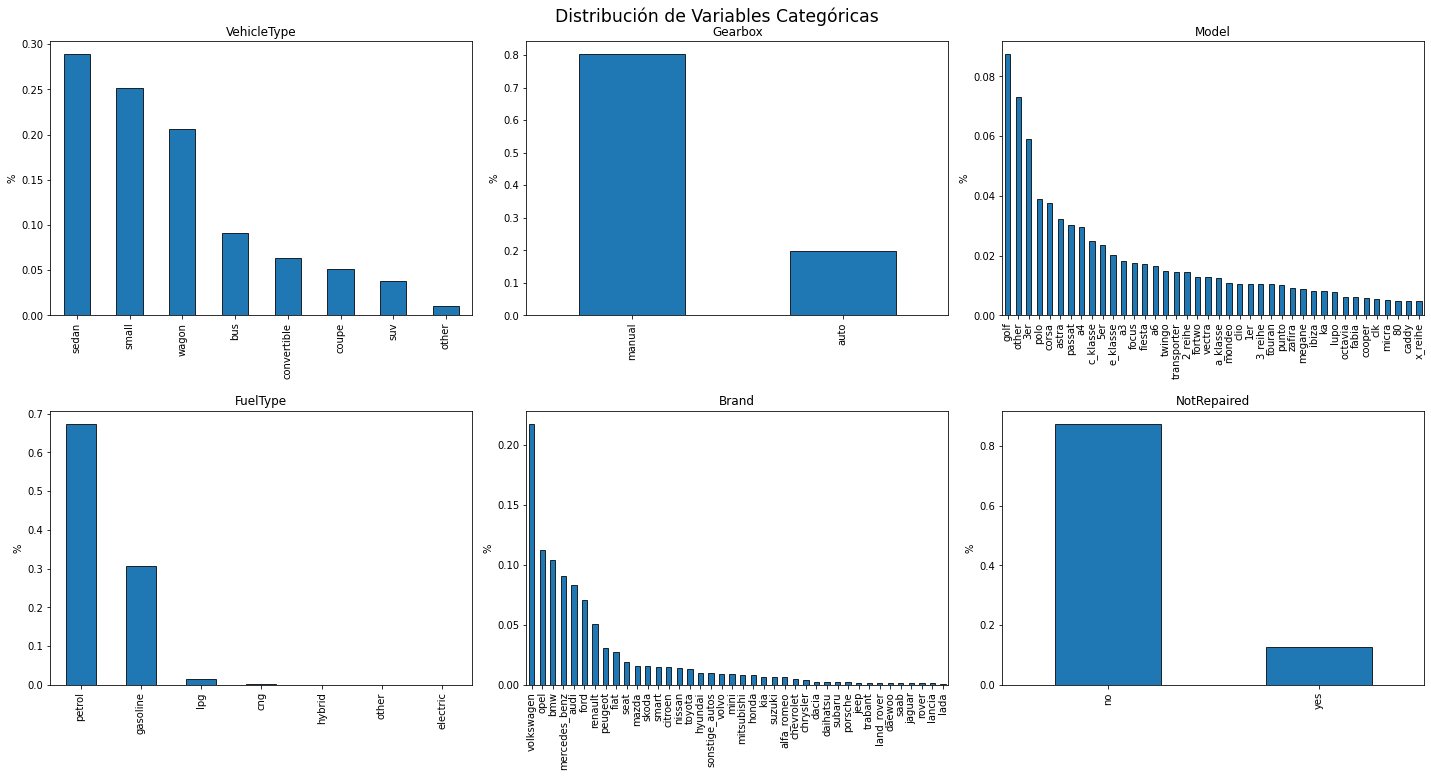

In [13]:
# Fija el número de filas y columnas para nuestros subplots
a = 3 # número de filas
b = 3 # número de columnas
c = 1 # inicialización del conteo de plots

# establece el tamaño de nuestra figura de subplots
fig = plt.subplots(figsize=(20, 15)) 

# construye un bucle for que iterará por cada columna categórica y devolverá un gráfico de barras
for i in categorical_data:
    plt.subplot(a, b, c) 
    plt.title(i)
    plt.ylabel('%')
    df[i].value_counts(normalize=True).head(40).plot(kind='bar', title=i, rot=90, edgecolor = 'black', linewidth = 0.8)
    c = c + 1

plt.suptitle('Distribución de Variables Categóricas', fontsize='xx-large')
plt.tight_layout()
plt.show()

Si se revisan las características categóricas, aparecen ocho tipos de vehículos, con un porcentaje mayor del tipo sedán (alrededor del 30%). Respecto al tipo de caja de cambios, existen dos tipos: manual y automática, con mayor proporción de transmisión manual (alrededor del 80%). Por otra parte, con relación al modelo, hay un porcentaje elevado de más del 80% de coches del modelo Golf, del total de 250 modelos matriculados. 

Respecto al tipo de combustible, existe mayor porcentaje de vehículos de petróleo y gasolina, con un 70% para los primeros y un 30% para los segundos. Hay que señalar que Gasoline se conoce como Petrol en el Reino Unido, así que debemos unir estas categorías en una sola. Por otro lado, una de las marcas con mayor número de anuncios online es Volkswagen (más del 20%), seguida de Opel (más del 10%) y BMW (alrededor del 10%). Finalmente, más del 80% de los vehículos son reparados, en tanto que el 20% restante no lo son. 

Cabe señalar que las características `VehicleType`, `Gearbox`, `Model`, `FuelType` y `NotRepaired` presentan valores perdidos, que se analizarán más adelante. 

A continuación llamaremos al método describir y generaremos histogramas de frecuencias para entender mejor la distribución de nuestras variables continuas.

In [14]:
df.describe()

,Price,RegistrationYear,Power,Mileage,RegistrationMonth,NumberOfPictures,PostalCode
count,354369.000000,354369.000000,354369.000000,354369.000000,354369.000000,354369.0,354369.000000
mean,4416.656776,2004.234448,110.094337,128211.172535,5.714645,0.0,50508.689087
std,4514.158514,90.227958,189.850405,37905.341530,3.726421,0.0,25783.096248
min,0.000000,1000.000000,0.000000,5000.000000,0.000000,0.0,1067.000000
25%,1050.000000,1999.000000,69.000000,125000.000000,3.000000,0.0,30165.000000
50%,2700.000000,2003.000000,105.000000,150000.000000,6.000000,0.0,49413.000000
75%,6400.000000,2008.000000,143.000000,150000.000000,9.000000,0.0,71083.000000
max,20000.000000,9999.000000,20000.000000,150000.000000,12.000000,0.0,99998.000000


En la columna `NumberOfPictures` se registran sólo valores cero, así que podemos ignorarla para el análisis posterior.

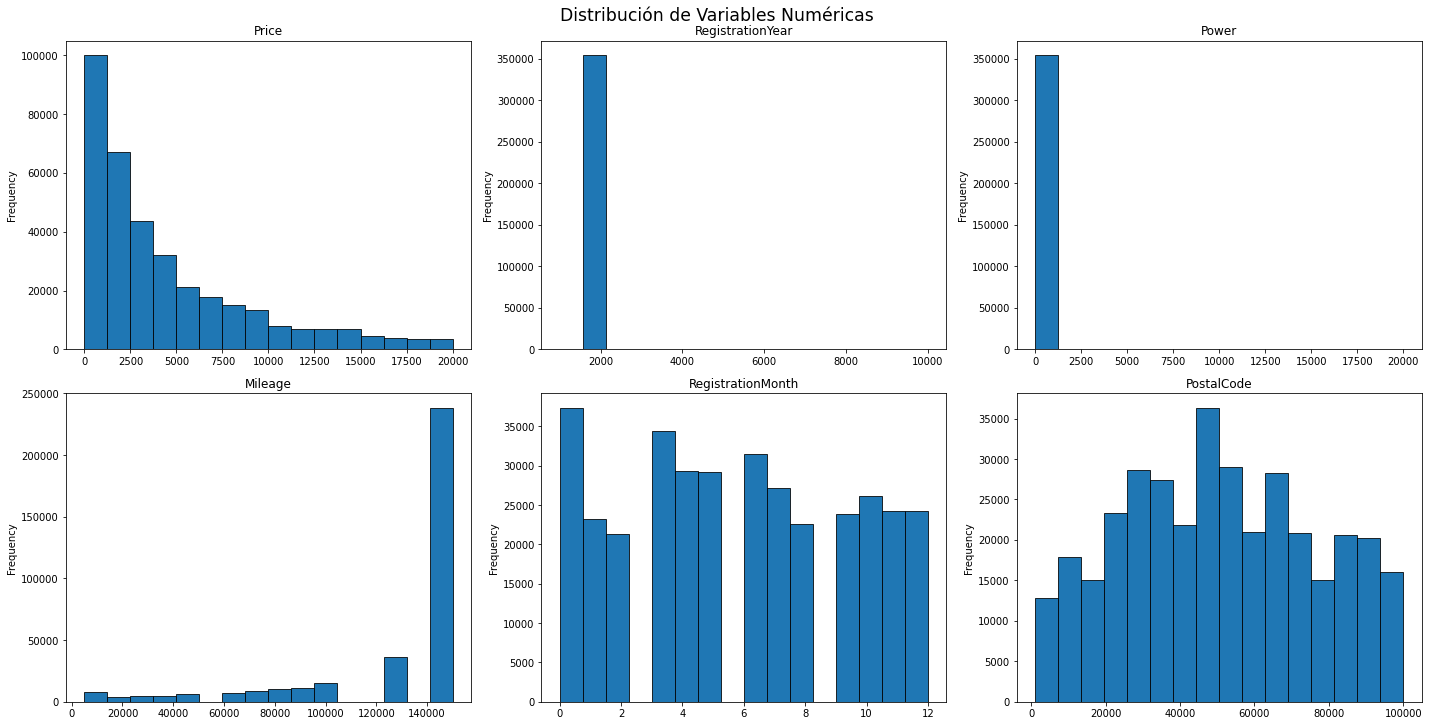

In [15]:
# ALmacena a las variables continuas en la variable numerical_data
numerical_data= ['Price', 'RegistrationYear', 'Power', 'Mileage', 'RegistrationMonth', 'PostalCode']

# Establece el número de filas y columnas para nuestros subplots
a = 3 # número de filas
b = 3 # número de columnas
c = 1 # inicialización del conteo de plots

# Establece el tamaño de nuestra figura de subplots
fig = plt.subplots(figsize=(20, 15)) 

#  bucle for que iterará por cada columna numérica y devolverá un histograma
for i in numerical_data:
    plt.subplot(a, b, c)
    plt.title(i)
    df[i].plot(kind='hist', title=i, bins=16, edgecolor = 'black', linewidth = 0.8)
    c = c + 1

plt.suptitle('Distribución de Variables Numéricas', fontsize='xx-large')
plt.tight_layout()
plt.show()

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class=“tocSkip”></a>
¡Felicidades por tu excelente trabajo al separar las variables cualitativas y analizarlas utilizando diferentes indicadores estadísticos y gráficos como los histogramas! Esta es una práctica muy valiosa en ciencia de datos ya que nos permite obtener una mejor comprensión de la distribución y frecuencia de las variables categóricas en nuestro conjunto de dato</div>

Respecto al precio se observa una media de 4416 dólares con una mediana de 2700, que indica un sesgo a la derecha para nuestros datos, hecho que se confirma al visualizar el histograma con una marcada asimetría positiva para los valores de precio, evidenciándose un alto porcentaje de valores cero o cercanos a cero, que también estaría en relación con la elevada desviación típica. Dichos valores pudieran estar vinculados a usuarios que no publican el precio del vehículo con el fin de que el comprador se contacte de forma directa con el vendedor, así que será preciso procesar adecuadamente estos valores cero para construir nuestro modelo predictivo.

Respecto al año de registro del vehículo, el promedio es 2004 y una mediana 2003, por lo que se registran más vehículos de estos años. No obstante, encontramos valores incoherentes, siendo el mínimo 1000 y el máximo 9999. Si tenemos en cuenta que el primer vehículo se creó en 1886, convendrá hacer un filtro de estos valores extremos para trabajar sólo con los vehículos de un máximo de 130 años. 

En cuanto a Power, se sitúa en torno a los 110 CV, siendo la mediana de 105 CV, indicando una asimetría positiva. Es evidente también el hecho de la presencia de valores incoherentes que llegan a los 20000cv, cuando el vehículo de mayor potencia registrada alcanza los 1825cv (Bugatti Bolide). Convendrá examinar estos valores y decidir qué hacer con ellos. 

El kilometraje (mileage) medio es de 128211, con una mediana de 1500000, lo que indica un sesgo a la izquierda en nuestros datos, que se hace evidente al analizar nuestro histograma de frecuencias, con un mayor número de vehículos por encima de 140000 km. Asimismo, se observan valores cero incoherentes en el mes de matriculación del vehículo, lo que estaría relacionado con que el usuario no facilita esta información. Finalmente, no se registraron valores atípicos en el código postal, sin embargo será necesario considerar si estas características ayudarán en la construcción de nuestro modelo. 

Terminaremos con la exploración inicial de los datos haciendo un análisis de correlación, para esto eliminaremos la columna `NumberOfPictures` puesto que solo registra valores cero y no será necesaria para la construcción de nuestro modelo predictivo.

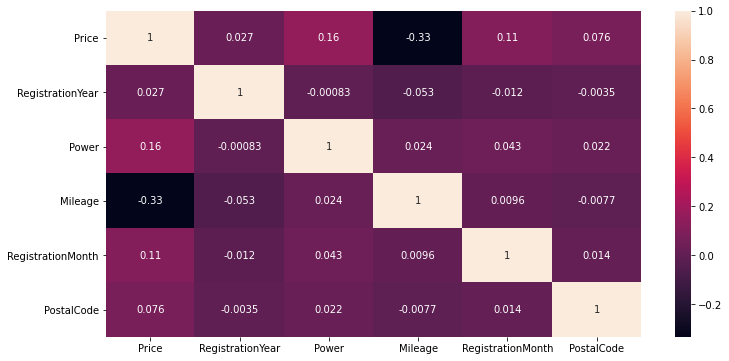

In [16]:
# Elimina la columna Number of Pictures con la función drop
df = df.drop(['NumberOfPictures'], axis=1)

# Traza un gráfico heatmap de correlación
plt.figure(figsize=(12, 6))
sns.heatmap(df.corr(), annot=True)
plt.show()

<div class="alert alert-block alert-info">
<b>Comentario del revisor</b> <a class=“tocSkip”></a>
Si estás trabajando con variables no lineales o con distribuciones no normales, es recomendable utilizar la correlación de Spearman en lugar de la correlación de Pearson.no asume que las variables tengan una distribución normal. En cambio, la correlación de Spearman se basa en los rangos de los datos, lo que la hace más robusta a la presencia de valores atípicos y a distribuciones no normales.
</div>

Entre el kilometraje y el precio del vehículo se aprecia una correlación negativa moderada: a mayor precio, menor kilometraje. Se observa también una leve correlación positiva entre el precio y la potencia, a mayor precio, mayor potencia del vehículo. Entre las otras características numéricas al no observarse una correlación lineal fuerte, puesto que todas presentan una correlación de Pearson cercana a cero, de existir una relación entre ellas no es de tipo lineal.

### Conclusiones

1. Las denominaciones de las columnas aparecen en mayúsculas de modo que deberán corregirse para que sigan las normas del buen estilo de programación. 
2. Los tipos de datos correspondientes a las columnas `DateCrawled`, `DateCreated` y `LastSeen` aparecen como objeto y lo correcto sería convertirlos a tipo datetime.
Se registran valores perdidos en cinco columnas `VehicleType`, `Gearbox`, `Model`, `FuelType` y `NotRepaired`, que deberán ser analizados para averiguar si existe algún patrón que nos permita imputarlos posteriormente. Asimismo, es preciso unir en una única categoría `petrol` y `gasoline` que son los mismos términos para referirse a la gasolina.
4. Como la columna o característica `NumberOfPictures` sólo presentaba valores nulos, se optó por eliminarla de nuestro conjunto de datos. 
5. Las características `Price`, `RegistrationYear` y `Power` mostraron artefactos extraños que tendrán que ser analizados y procesados correctamente antes de construir nuestro modelo, estas inconsistencias son: 
    `Price` valores iguales a cero 2.
    2. Años de registro de 1000 y 9999.
    3. Valores de potencia de 0 y 20000. 
    4. Mes de matriculación del vehículo igual a cero.
    
6. Algunas características, como la fecha o el código postal, no serán útiles para construir nuestro modelo, por lo que será necesario tomar una decisión sobre si conservarlas o no.

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class=“tocSkip”></a>
¡Felicitaciones por incluir conclusiones intermedias en su proyecto! Esto es una práctica excelente ya que ayuda a comprender mejor los datos y a tomar decisiones informadas en la siguiente etapa del análisis. Continúa haciendo esto en futuros proyectos.</div>

## Preparación de datos

### Valores duplicados
Durante la exploración de datos se observaron valores duplicados, así que lo mejor será eliminarlos

In [17]:
df = df.drop_duplicates().reset_index(drop=True)

print(f'Número de valores duplicados: {df.duplicated().sum()} | Número de filas dataset: {df.shape[0]}')

Número de valores duplicados: 0 | Número de filas dataset: 354107


### Corrección nombres de columnas 
Se empieza rectificando el nombre de las columnas que estaban en mayúsculas, convirtiéndolas en minúsculas y separando los nombres con más de dos palabras con un guión bajo. Para esto usaremos expresiones regulares y las funciones `str.replace`, `str.strip` y `str.lower`.

In [18]:
# cambia los nombres a minúsculas y añadimos un guión bajo como separador de palabras.
df.columns = df.columns.str.replace(r'([A-Z])', r'_\1', regex=True).str.strip('_').str.lower()


In [19]:

# comprueba los cambios mostrando los nombres de las columnas.
df.columns

Index(['date_crawled', 'price', 'vehicle_type', 'registration_year', 'gearbox',
       'power', 'model', 'mileage', 'registration_month', 'fuel_type', 'brand',
       'not_repaired', 'date_created', 'postal_code', 'last_seen'],
      dtype='object')

### Corrección tipo de datos
Las columnas `date_crawled`, `date_created` y `last_seen` están presentadas como tipo objeto, así que será por tanto preciso transformarlas a tipo datetime, ya que serán útiles a la hora de extraer información relevante como es el año de publicación, del que posteriormente calcularemos el año del vehículo.

In [20]:
# guarda las columnas de fecha en la variable date_columns
date_columns = df[['date_crawled', 'date_created', 'last_seen']]

# construye un bucle for que itere por las columnas y las transforme en datetime
for col in date_columns:
    df[col] = pd.to_datetime(df[col], format='%d/%m/%Y %H:%M')

# verifica los cambios
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 354107 entries, 0 to 354106
Data columns (total 15 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   date_crawled        354107 non-null  datetime64[ns]
 1   price               354107 non-null  int64         
 2   vehicle_type        316623 non-null  object        
 3   registration_year   354107 non-null  int64         
 4   gearbox             334277 non-null  object        
 5   power               354107 non-null  int64         
 6   model               334406 non-null  object        
 7   mileage             354107 non-null  int64         
 8   registration_month  354107 non-null  int64         
 9   fuel_type           321218 non-null  object        
 10  brand               354107 non-null  object        
 11  not_repaired        282962 non-null  object        
 12  date_created        354107 non-null  datetime64[ns]
 13  postal_code         354107 no

### Valores ausentes
Hay cinco columnas registradas con valores perdidos, por lo que debemos calcular el porcentaje que representan en nuestro conjunto de datos.

In [21]:
nan_count = df.isna().sum()
nan_percent = 100 * df.isna().sum() / len(df)
       
nan_table = pd.concat([nan_count, nan_percent], axis=1)
nan_table.columns = ['Valores Ausentes', '% Ausentes']

nan_table[nan_table.iloc[:,1] != 0]

,Valores Ausentes,% Ausentes
vehicle_type,37484,10.585501
gearbox,19830,5.600002
model,19701,5.563573
fuel_type,32889,9.287871
not_repaired,71145,20.091385


La característica `not_repaired` presenta el mayor porcentaje de valores ausentes 20%, seguida de `vehicle_type` con un 10% y `fuel_type` con un 9%. Tanto `gearbox` como `model` registran cerca de un 5% de valores NaN. 

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class=“tocSkip”></a>
Excelente. Hice un comentario respecto a esto, pero veo que acá lo incluyes..</div>

#### Valores ausentes `gearbox`
El tipo de caja de cambios se relaciona directamente con el modelo del coche y su marca, así que completaremos los valores perdidos en base al modo de estas dos características. Tenemos que considerar que `model` contiene valores perdidos así que será preciso trabajar con un conjunto de datos filtrado que no presente ningún valor perdido tanto en `gearbox` como en `model`. Para ello crearemos una función `fill_gearbox` que completará los valores perdidos con la moda y en caso de que no sea posible devolverá la palabra Error.

In [23]:
# analiza la distribución de nuestros datos
df['gearbox'].value_counts(dropna=False, normalize=True)

manual    0.756929
auto      0.187071
NaN       0.056000
Name: gearbox, dtype: float64

In [24]:
# filtra el dataset sin valores ausentes en 'gearbox' y 'model', y creamos una tabla dinámica que devuelva la moda 
gearbox_without_nan = df.dropna(subset=['gearbox', 'model'])
gearbox_model = gearbox_without_nan.pivot_table(index=['brand','model'], values='gearbox', aggfunc=mode)

# crea la función fill_gearbox
def fill_gearbox(row):
    '''
    Devuelve la moda de la caja de cambios en función del modelo y marca del auto, si no es posible lanzará 'Error'
    
    :param row: fila con la información que requiere ser rellenada
    '''
    model = row['model']
    gearbox = row['gearbox']
    brand = row['brand']

    if pd.isna(gearbox):
        try:
            return gearbox_model.loc[(brand, model), 'gearbox']
        except:
            return 'Error'
    return gearbox

# verifica que la función trabaje correctamente
row_values = ['alfa_romeo', '145', np.nan]
row_columns = ['brand', 'model', 'gearbox']
row = pd.Series(data=row_values, index=row_columns)
fill_gearbox(row)

'manual'

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class=“tocSkip”></a>
Correcta, imputación de datos con la moda. : )</div>

In [25]:
# aplica la función a nuestro dataset
df['gearbox'] = df.apply(fill_gearbox, axis = 1)

# verifica si existen valores que no se rellenaron
errors = df[df['gearbox'] == 'Error']
print(f'Errores al aplicar la función fill_model: {len(errors)}')

Errores al aplicar la función fill_model: 4130


La función no ha conseguido rellenar 4130 valores, por lo que los valores restantes se rellenarán basándose en el moda de toda la columna. Optamos por sustituir por el moda, dado que sólo hay dos opciones manual y auto, y manual es la más probable, con lo que no afectaríamos sobre la distribución de nuestros datos. Utilizaremos entonces la función sustituir para modificar los Errores por la moda y verificaremos que los modificaciones se han realizado correctamente.

In [26]:
# reemplaza los errores por la moda de la columna
df['gearbox'] = df['gearbox'].replace('Error', mode(df['gearbox']))

# comprueba los cambios realizados 
print('Número de errores en model:', len(df[df['model'] == 'Error']))
print('Valores únicos en gearbox:')
print(df['gearbox'].value_counts(dropna=False, normalize=True))

Número de errores en model: 0
Valores únicos en gearbox:
manual    0.807423
auto      0.192577
Name: gearbox, dtype: float64


#### Valores ausentes `vehicle_type`
Según el modelo y la marca del vehículo, se utilizará esta variable para rellenar los valores que falten.

In [27]:
# analiza la distribución de nuestros datos
df['vehicle_type'].value_counts(dropna=False, normalize=True)

sedan          0.258111
small          0.225223
wagon          0.183885
NaN            0.105855
bus            0.081196
convertible    0.056988
coupe          0.045599
suv            0.033863
other          0.009280
Name: vehicle_type, dtype: float64

In [28]:
# filtra los valores ausentes en las columnas 'model' y 'vehicle_type' y construimos una tabla dinámica
vehicletype_without_nan = df.dropna(subset=['vehicle_type', 'model'])
vehicletype_model = vehicletype_without_nan.pivot_table(index=['brand','model'], values='vehicle_type', aggfunc=mode)

# crea la función fill_vehicle_type
def fill_vehicle_type(row):
    '''
    Devuelve la moda en función de del modelo y marca del auto, si no es posible devuelve 'Error'
    
    :param row: fila con la información que requiere ser rellenada
    '''
    brand = row['brand']
    model = row['model']
    vehicle_type = row['vehicle_type']
    
    if pd.isna(vehicle_type):
        try:
            return vehicletype_model.loc[(brand, model), 'vehicle_type']
        except:
            return 'Error'
    return vehicle_type

# comprueba que la función trabaje correctamente
row_values = ['alfa_romeo', '145', np.nan]
row_columns = ['brand', 'model', 'vehicle_type']
row = pd.Series(data=row_values, index=row_columns)
fill_vehicle_type(row)

'small'

In [29]:
# aplica la función a nuestro dataset
df['vehicle_type'] = df.apply(fill_vehicle_type, axis = 1)

# comprueba si existen valores que no se rellenaron
errors = df[df['vehicle_type'] == 'Error']
print(f'Errores al aplicar la función fill_vehicle_type: {len(errors)}')

Errores al aplicar la función fill_vehicle_type: 6827


Había 6827 valores que no se pudieron rellenar, por lo que los sustituiremos por la palabra unknown puesto que no podemos obtener este valor de otra variable

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class=“tocSkip”></a>
Correcto!</div>

In [30]:
# Reemplazamos los errores por la moda de la columna
df['vehicle_type'] = df['vehicle_type'].replace('Error', 'unknown')

# verifica los cambios realizados 
print('Número de errores en vehicle_type:', len(df[df['vehicle_type'] == 'Error']))
print('Valores únicos en vehicle_type:')
print(df['vehicle_type'].value_counts(dropna=False, normalize=True))

Número de errores en vehicle_type: 0
Valores únicos en vehicle_type:
sedan          0.293838
small          0.250964
wagon          0.193882
bus            0.091811
convertible    0.057757
coupe          0.047367
suv            0.035755
unknown        0.019279
other          0.009347
Name: vehicle_type, dtype: float64


#### Valores ausentes `fuel_type`
Se ha dicho antes que los tipos de combustible gasolina y gasóleo son términos con el mismo significado, con la única diferencia del lugar donde se utilizan. Petrol se utiliza en el Reino Unido y la India, mientras que gasoline se usa en Estados Unidos. Por tanto, lo mejor es reunirlos en una sola categoría

In [31]:
# reemplaza petrol pr gasoline
df['fuel_type'] = df['fuel_type'].replace('petrol', 'gasoline')

# verific la nueva distribución de los datos
df['fuel_type'].value_counts(dropna=False, normalize=True)

gasoline    0.889050
NaN         0.092879
lpg         0.014987
cng         0.001596
hybrid      0.000658
other       0.000576
electric    0.000254
Name: fuel_type, dtype: float64

A continuación, completaremos los valores ausentes en función del modelo de vehículo. Crearemos una función y la aplicaremos a la característica `fuel_type`.

In [32]:
# filtra los valores ausentes en la columna 'model'  y construimos una tabla dinámica
fuel_without_nan = df.dropna(subset=['fuel_type', 'model'])
fuel_model = fuel_without_nan.pivot_table(index=['model'], values='fuel_type', aggfunc=mode)

# Creamos la función fill_vehicle_type
def fill_fuel_type(row):
    '''
    Devuelve la moda en función del modelo del auto, si no es posible devuelve 'Error'
    
    :param row: fila con la información que requiere ser rellenada
    '''
    model = row['model']
    fuel_type = row['fuel_type']
    
    if pd.isna(fuel_type):
        try:
            return fuel_model.loc[model, 'fuel_type']
        except:
            return 'Error'
    return fuel_type

# Comprobamos que la función trabaje correctamente
row_values = ['100', np.nan]
row_columns = ['model', 'fuel_type']
row = pd.Series(data=row_values, index=row_columns)
fill_fuel_type(row)

'gasoline'

In [33]:
# aplica la función a nuestro dataset
df['fuel_type'] = df.apply(fill_fuel_type, axis = 1)

# verifica si existen valores que no se rellenaron
errors = df[df['fuel_type'] == 'Error']
print(f'Errores al aplicar la función fill_fuel_type: {len(errors)}')

Errores al aplicar la función fill_fuel_type: 7161


No se pudieron rellenar 7161 valores, así que los sustituiremos por `unknown`.

In [34]:
# reemplaza los errores por la moda de la columna
df['fuel_type'] = df['fuel_type'].replace('Error', 'unknown')

# verifica los cambios realizados 
print('Número de errores en fuel_type:', len(df[df['fuel_type'] == 'Error']))
print('Valores únicos en fuel_type:')
print(df['fuel_type'].value_counts(dropna=False, normalize=True))

Número de errores en fuel_type: 0
Valores únicos en fuel_type:
gasoline    0.961706
unknown     0.020223
lpg         0.014987
cng         0.001596
hybrid      0.000658
other       0.000576
electric    0.000254
Name: fuel_type, dtype: float64


#### Valores ausentes `model`
Empezaremos completando los valores faltantes del modelo, para este caso usaremos como variables de referencia la marca del vehículo y el año de matriculación, puesto que el modelo de coche está directamente relacionado con la marca y algunos modelos salieron al mercado en años concretos. Para ayudarnos a rellenar los valores partiendo de la moda por marca y año de matriculación crearemos una función `fill_model`.

In [35]:
# filtra el dataset sin valores ausentes en 'model' y creamos una tabla dinámica que devuelva la moda 
model_without_nan = df.dropna(subset=['model'])
model_brand = model_without_nan.pivot_table(index=['brand', 'registration_year'], values='model', aggfunc=mode)

# Creamos la función fill_model
def fill_model(row):
    '''
    Devuelve la moda en función de la marca y año de matriculación del auto, si no es posible devuelve 'Error'
    
    :param row: fila con la información que requiere ser rellenada
    '''
    model = row['model']
    registration_year = row['registration_year']
    brand = row['brand']
    
    if pd.isna(model):
        try:
            return model_brand.loc[(brand, registration_year), 'model']
        except:
            return 'Error'
    return model

# comprueba que la función trabaje correctamente
row_values = ['volvo', 2013, np.nan]
row_columns = ['brand', 'registration_year', 'model']
row = pd.Series(data=row_values, index=row_columns)
fill_model(row)

'v60'

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class=“tocSkip”></a>
Muy bien por la moda condicionada.</div>

In [36]:
# aplica la función a nuestro dataset
df['model'] = df.apply(fill_model, axis = 1)

# comprueba si existen valores que no se rellenaron
errors = df[df['model'] == 'Error']
print(f'Errores al aplicar la función fill_model: {len(errors)}')

Errores al aplicar la función fill_model: 3441


Cuando aplicamos la función `fill_model`, se generaron 3441 valores de Error, se trataría de modelos de vehículos que no han podido ser rellenados a partir de su marca y año de matriculación. Por lo tanto, al no poder utilizar otra variable de referencia, se van a rellenar con la palabra `unknown`, ya que no conocemos los modelos de estos vehículos.

In [37]:
df['model'] = df['model'].replace('Error', 'unknown')

print('Número de errores en model:', len(df[df['model'] == 'Error']))

Número de errores en model: 0


#### Valores ausentes `not_repaired`
Que un vehículo esté reparado o no depende de cada proveedor, por lo que los valores que faltan en esta columna no son algo que pueda rellenarse fácilmente basándose en otra variable. Estos valores podrían rellenarse con una nueva categoría, pero esta vez crearemos un modelo de aprendizaje automático que prediga el estado de un vehículo basándose en todas las características del conjunto de datos. 

Comenzaremos por convertir esta característica categórica en una característica numérica, para lo cual crearemos un diccionario y, a continuación, utilizaremos la función map para sustituir no = 0 y sí = 1.

In [38]:
# crea un diccionario que guarde las equivalencias numéricas de yes y no
not_repaired_dict = {'no': 0, 'yes': 1}

# utiliza la función map a la columna not_repaired
df['not_repaired'] = df['not_repaired'].map(not_repaired_dict)

# comprueba los cambios
df['not_repaired'].value_counts(dropna=False, normalize=True)

0.0    0.697323
NaN    0.200914
1.0    0.101763
Name: not_repaired, dtype: float64

Ahora vamos a construir un modelo de regresión logística para predecir si un vehículo ha sido reparado o no, y completar los valores que faltan basándonos en las predicciones. Comenzamos codificando las características categóricas mediante la codificación One-Hot.

In [39]:
# Aplica OHE a nuestro dataset a través de la función get_dummies
df_ohe = pd.get_dummies(df, drop_first=True)

# Comprobamos si se guardaron los cambios
df_ohe.head(3)

,date_crawled,price,registration_year,power,mileage,registration_month,not_repaired,date_created,postal_code,last_seen,...,brand_seat,brand_skoda,brand_smart,brand_sonstige_autos,brand_subaru,brand_suzuki,brand_toyota,brand_trabant,brand_volkswagen,brand_volvo
0,2016-03-24 11:52:00,480,1993,0,150000,0,NaN,2016-03-24,70435,2016-04-07 03:16:00,...,0,0,0,0,0,0,0,0,1,0
1,2016-03-24 10:58:00,18300,2011,190,125000,5,1.0,2016-03-24,66954,2016-04-07 01:46:00,...,0,0,0,0,0,0,0,0,0,0
2,2016-03-14 12:52:00,9800,2004,163,125000,8,NaN,2016-03-14,90480,2016-04-05 12:47:00,...,0,0,0,0,0,0,0,0,0,0


Procederemos a entrenar nuestro modelo de regresión logística. No usaremos fechas para la predicción, pues no son variables importantes y el formato fecha-hora no funciona en la construcción del modelo.

In [40]:
# crea un conjunto de datos sin valores ausentes en not_repaired y otros con solo los valores ausentes 
nan_df_ohe = df_ohe[df_ohe['not_repaired'].isna()]
no_nan_df_ohe = df_ohe[~df_ohe['not_repaired'].isna()]

# Construcción de nuestro modelo de regresión lineal en base a nuestro dataset codificado sin valores ausentes
lr_nan = LogisticRegression(random_state=12345, solver='liblinear')
lr_nan.fit(no_nan_df_ohe.drop(columns=['not_repaired', 'date_crawled', 'date_created', 'last_seen']), 
           no_nan_df_ohe['not_repaired'])

# reemplazo de valores ausentes con las predicciones realizadas por nuestro modelo
df['not_repaired'].fillna(pd.Series
                          (lr_nan.predict(nan_df_ohe.drop(columns=['not_repaired', 'date_crawled', 'date_created', 'last_seen'])), 
                           index=nan_df_ohe.index),
                          inplace=True)

# transforma del tipo de dato a entero 
df['not_repaired'] = df['not_repaired'].astype('int')

# comprueba de cambios
df['not_repaired'].value_counts(dropna=False, normalize=True)

0    0.898189
1    0.101811
Name: not_repaired, dtype: float64

Por último, comprobamos que no faltan valores en nuestro conjunto de datos.

In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 354107 entries, 0 to 354106
Data columns (total 15 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   date_crawled        354107 non-null  datetime64[ns]
 1   price               354107 non-null  int64         
 2   vehicle_type        354107 non-null  object        
 3   registration_year   354107 non-null  int64         
 4   gearbox             354107 non-null  object        
 5   power               354107 non-null  int64         
 6   model               354107 non-null  object        
 7   mileage             354107 non-null  int64         
 8   registration_month  354107 non-null  int64         
 9   fuel_type           354107 non-null  object        
 10  brand               354107 non-null  object        
 11  not_repaired        354107 non-null  int64         
 12  date_created        354107 non-null  datetime64[ns]
 13  postal_code         354107 no

### Valores atípicos y artefactos
Al efectuar una primera exploración de los datos, detectamos valores inusuales en algunas columnas del conjunto de datos: `price`, `registration_year`, `power`, `registration_month`. Analizaremos cada uno de estos valores y determinaremos cómo procesarlos. Trazaremos gráficos de caja que nos permitirán mostrar esos valores atípicos e inconsistentes en nuestro conjunto de datos, para esto crearemos la función `boxplot_function`.

In [42]:
def boxplot_function(df, column, ylim=(0,0)):
    """
    Devuelve un diagrama de cajas con sus rangos intercuartílicos
    
    :param df: nombre del dataset    
    :param size: nombre de la columna como string
    :param seed: límites del eje y del gráfico
    
    """
    Q1= df[column].quantile(0.25)
    Q3= df[column].quantile(0.75)
    IQR = Q3 - Q1

    df.boxplot(column)
    plt.ylim(ylim)
    plt.hlines(y=[(Q1-1.5*IQR),(Q3+1.5*IQR)], xmin=0.9, xmax=1.1, color='red')
    plt.show()

#### Valores atípicos `registration_year`
Ahora vamos a aplicar la función boxplot_function a la columna `registration_year` y establecer las fechas en que se registraron la mayoría de los usuarios.

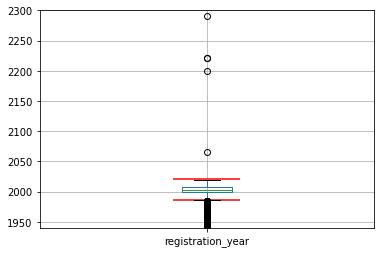

In [43]:
boxplot_function(df, 'registration_year', (1940, 2300))

In [44]:
print(f'''Fecha más antigua de registro: {df['date_created'].min()}
Fecha más reciente de registro: {df['date_created'].max()}
Número de años que abarcan los datos: {df['date_created'].dt.year.max() - df['date_created'].dt.year.min()}''')

Fecha más antigua de registro: 2014-03-10 00:00:00
Fecha más reciente de registro: 2016-04-07 00:00:00
Número de años que abarcan los datos: 2


Observamos en nuestro diagrama de cajas anomalías con años de matriculación superiores a 2060 e inferiores a 1900. Considerando que el coche se inventó en el año de 1886 y que los registros de datos son hasta el año 2016. Sólo consideraremos los datos comprendidos entre 1900 y 2016. Como no podemos sustituir o predecir el año de matriculación en función de otras variables, entonces filtraremos el conjunto de datos en función de estos valores.

In [45]:
# filtra nuestro dataset
df_filtered = df.query('1900 <= registration_year <= 2016')

# comprueba los cambios 
df_filtered['registration_year'].describe() 

count    339512.000000
mean       2002.481859
std           7.091857
min        1910.000000
25%        1999.000000
50%        2003.000000
75%        2007.000000
max        2016.000000
Name: registration_year, dtype: float64

In [46]:
print(f'Porcentaje de valores eliminados: {(len(df) - len(df_filtered))*100/len(df)}')
print(f'Tamaño del dataset filtrado en registration_year: {len(df_filtered)}')

Porcentaje de valores eliminados: 4.121635550836329
Tamaño del dataset filtrado en registration_year: 339512


#### Valores atípicos `price`
En el precio de venta del vehículo se han registrado valores cero, esto esta relacionado con aquellos vendedores que prefieren al comprador para que se ponga en contacto con ellos directamente al no poner el precio del vehículo, aplicaremos nuestra función boxplot_function a la columna precio y veremos la distribución de los datos para tomar una mejor decisión.

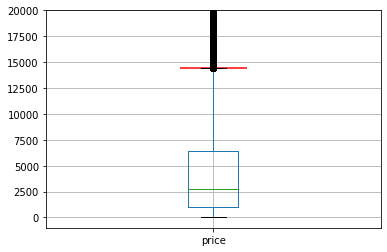

In [47]:
boxplot_function(df, 'price', (-1000, 20000))

El gráfico de caja presenta una asimetría positiva, antes mencionada, que guarda relación con el gran número de valores próximos a cero en nuestro conjunto de datos. Como construiremos nuestro modelo para predecir estos valores, descartaremos los vehículos con precios inferiores a 99 $, ya que suponen artefactos extraños que afectarían a nuestro modelo.

In [48]:
filtra nuestro dataset
df_filtered = df_filtered.query('99 <= price')

# comprueba los cambios 
df_filtered['price'].describe() 

count    327172.000000
mean       4639.560433
std        4546.098270
min          99.000000
25%        1200.000000
50%        2950.000000
75%        6700.000000
max       20000.000000
Name: price, dtype: float64

In [49]:
print(f'Porcentaje de valores eliminados: {(339512 - len(df_filtered))*100/339512}')

Porcentaje de valores eliminados: 3.6346285256485777


In [50]:
print(f'Porcentaje de valores anormales eliminados en total: {(len(df) - len(df_filtered))*100/len(df)}')

Porcentaje de valores anormales eliminados en total: 7.606457935030937


#### Valores atípicos `power`
A continuación veremos los valores atípicos en la columna "potencia", que tiene un valor máximo de 20000 CV y un valor mínimo de 0 CV, que son valores extraños para la potencia de un vehículo. Aplicaremos nuestra función `boxplot_function` a esta columna.

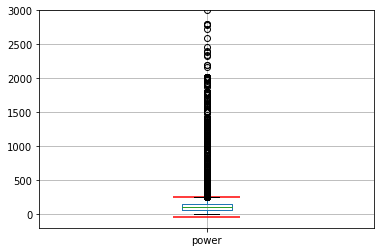

In [51]:
boxplot_function(df, 'power', (-200, 3000))

Si analizamos nuestro diagrama de caja visualizaremos valores atípicos cercanos a cero y superiores a 3000cv, si consideramos que el valor mínimo de caballos para un vehículo es de 60cv y que el máximo puede llegar hasta 1800cv. Completaremos todos los valores inferiores de caballos de potencia con NaN y después analizaremos la posibilidad de reemplazarlos en función de otras variables. Eliminaremos los valores superiores a 2000 CV por ser valores atípicos.

In [52]:
# Filtra nuestro dataset df_filtered por aquellos valores mayores a 2000cv
df_filtered = df_filtered.query('power <= 2000')

# convierte los valores extraños en Nan
df_filtered.loc[df_filtered['power'] < 50, 'power'] = np.nan

# comprueba los cambios
df_filtered['power'].describe() 

count    290012.000000
mean        123.021723
std          62.829852
min          50.000000
25%          80.000000
50%         115.000000
75%         150.000000
max        2000.000000
Name: power, dtype: float64

In [53]:
nan_power = df_filtered[df_filtered['power'].isna()]
print(f'Porcentaje de valores extraños reemplazados por Nan: {nan_power.shape[0]/len(df_filtered)*100}')
print(f'Porcentaje de valores anormales eliminados en total: {(len(df) - len(df_filtered))*100/len(df)}')
print(f'Tamaño del dataset filtrado: {len(df_filtered)}')

Porcentaje de valores extraños reemplazados por Nan: 11.330567369164493
Porcentaje de valores anormales eliminados en total: 7.634980387284069
Tamaño del dataset filtrado: 327071


Observamos un elevado porcentaje de artefactos extraños reemplazados por valores NaN, por lo que vamos a rellenarlos según el modelo de vehículo.

In [54]:
# crea un dataset filtrado sin valores ausentes en power y construimos una tabla dinámica agrupando por model
power_no_missing_values = df_filtered.dropna(subset=['power'])
power_model = power_no_missing_values.pivot_table(index=['model'], values='power', aggfunc='median')

# crea la función fill_power
def fill_power(row):
    '''
    Devuelve la mediana en función del modelo del auto, si no es posible devuelve 'Error'
    
    :param row: fila con la información que requiere ser rellenada
    '''
    model = row['model']
    power = row['power']
    
    if pd.isna(power):
        try:
            return power_model.loc[model, 'power']
        except:
            return 'Error'
    return power

# verifica que la función trabaje correctamente
row_values = ['100', np.nan]
row_columns = ['model', 'power']
row = pd.Series(data=row_values, index=row_columns)
fill_power(row)

133.0

In [55]:
# Aplica la función a nuestro dataset
df_filtered['power'] = df_filtered.apply(fill_power, axis = 1)

In [56]:
# verifica si existen valores que no se rellenaron
df_filtered[df_filtered['power'] == 'Error']

,date_crawled,price,vehicle_type,registration_year,gearbox,power,model,mileage,registration_month,fuel_type,brand,not_repaired,date_created,postal_code,last_seen
234175,2016-03-30 11:39:00,3800,wagon,1978,manual,Error,serie_1,30000,0,gasoline,land_rover,0,2016-03-30,49824,2016-03-30 11:39:00


No se ha rellenado correctamente uno de los valores de potencia, este corresponde al vehículo Land Rover serie 1. Para esta marca y modelo de vehículo la potencia es de 50cv, por lo que rellenaremos este valor NaN con la información consultada.

In [57]:
# coloca el valor de potencia correspondiente al modelo del vehículo
df_filtered.loc[df_filtered['power'] == 'Error', 'power'] = 50

# convierte power en tipo entero
df_filtered['power'] = df_filtered['power'].astype('int')

# verifica los resultados
print('Número de errores en power:', len(df_filtered[df_filtered['power'] == 'Error']))
print(df_filtered['power'].describe())

Número de errores en power: 0
count    327071.000000
mean        120.832834
std          60.931922
min          50.000000
25%          75.000000
50%         110.000000
75%         147.000000
max        2000.000000
Name: power, dtype: float64


#### Valores atípicos `registration_month`
Cuando exploramos el conjunto de datos inicial hallamos valores cero en el mes de matrícula del vehículo, que podrían estar relacionados con el hecho de que el vendedor no facilitó esa información. Por ello lo sustituiremos por la mediana de la columna.

In [58]:
# comprueba el recuento de valores únicos para registration_month
df_filtered['registration_month'].value_counts(normalize=True)

3     0.099498
6     0.090531
0     0.086415
4     0.084141
5     0.083811
7     0.078463
10    0.075549
11    0.070025
12    0.069707
9     0.069016
1     0.066560
8     0.065029
2     0.061256
Name: registration_month, dtype: float64

Sustituimos los valores cero por la mediana del mes de inscripción y comprobamos los cambios llamando a `value_counts`.

In [59]:
# reemplaza los valores cero por la mediana de la columna
df_filtered['registration_month'] = (df_filtered['registration_month'].replace(0, 
                                                                              df_filtered['registration_month'].median())
                                     .astype('int'))

# verifica los cambios realizados
df_filtered['registration_month'].value_counts(normalize=True)

6     0.176946
3     0.099498
4     0.084141
5     0.083811
7     0.078463
10    0.075549
11    0.070025
12    0.069707
9     0.069016
1     0.066560
8     0.065029
2     0.061256
Name: registration_month, dtype: float64

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class=“tocSkip”></a>
Excelente análisis de los valores atípicos. </div>

#### Cálculo edad del vehículo
A continuación, añadiremos una nueva función en el conjunto de datos `car_age` que comienza a partir del año en que se creó el perfil de usuario y el año en que se matriculó el vehículo.

In [60]:
# calcula la edad de cada vehículo
df_filtered['car_age'] = df_filtered['date_created'].dt.year - df['registration_year']

# verifica los valores calculados
df_filtered['car_age'].describe()

count    327071.000000
mean         13.376888
std           6.864718
min           0.000000
25%           9.000000
50%          13.000000
75%          17.000000
max         106.000000
Name: car_age, dtype: float64

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class=“tocSkip”></a>
Correcto. era necesario arreglar los datos para la fecha></div>

#### Dataset Final
Terminamos por filtrar todas aquellas columnas que no nos serán útiles en la construcción de nuestros modelos. Concretamente eliminaremos las características de fecha, código postal y fecha de matriculación, para esta ultima hemos creado la nueva columna car_age que presenta los años del vehículo y se relacionaría con el año de matriculación del vehículo.

In [61]:
df_final = df_filtered.drop(['date_crawled', 'registration_year','registration_month', 'date_created', 'postal_code', 'last_seen'], axis=1)

df_final.head()

,price,vehicle_type,gearbox,power,model,mileage,fuel_type,brand,not_repaired,car_age
0,480,sedan,manual,101,golf,150000,gasoline,volkswagen,0,23.0
1,18300,coupe,manual,190,a4,125000,gasoline,audi,1,5.0
2,9800,suv,auto,163,grand,125000,gasoline,jeep,0,12.0
3,1500,small,manual,75,golf,150000,gasoline,volkswagen,0,15.0
4,3600,small,manual,69,fabia,90000,gasoline,skoda,0,8.0


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class=“tocSkip”></a>
Muy bien , un dataset muy concreto y limpio</div>

In [62]:
df_final.describe()

,price,power,mileage,not_repaired,car_age
count,327071.000000,327071.000000,327071.000000,327071.000000,327071.000000
mean,4639.853903,120.832834,128359.973828,0.099128,13.376888
std,4546.295861,60.931922,37257.806549,0.298835,6.864718
min,99.000000,50.000000,5000.000000,0.000000,0.000000
25%,1200.000000,75.000000,125000.000000,0.000000,9.000000
50%,2950.000000,110.000000,150000.000000,0.000000,13.000000
75%,6700.000000,147.000000,150000.000000,0.000000,17.000000
max,20000.000000,2000.000000,150000.000000,1.000000,106.000000


In [63]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 327071 entries, 0 to 354106
Data columns (total 10 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   price         327071 non-null  int64  
 1   vehicle_type  327071 non-null  object 
 2   gearbox       327071 non-null  object 
 3   power         327071 non-null  int64  
 4   model         327071 non-null  object 
 5   mileage       327071 non-null  int64  
 6   fuel_type     327071 non-null  object 
 7   brand         327071 non-null  object 
 8   not_repaired  327071 non-null  int64  
 9   car_age       327071 non-null  float64
dtypes: float64(1), int64(4), object(5)
memory usage: 35.5+ MB


## Entrenamiento del modelo 

Una vez corregidos los valores ausentes y los valores atípicos, se procede a elaborar varios modelos de aprendizaje automático conformes. Compararemos los modelos de árbol de decisión, bosque aleatorio y regresión lineal con los métodos de refuerzo de gradiente LightGBM, CatBoost y XGBoost: LightGBM, CatBoost y XGBoost. En este conjunto de datos, las características `brand` y `model` tienen 40 y 250 categorías respectivamente, así que habrá que considerar qué método de codificación se usará para cada modelo, ya que serían variables de alta cardinalidad. Así por ejemplo, One-Hot Encoding será útil para nuestro modelo de regresión lineal, mientras que no lo será para nuestros modelos de árbol, ya que éstos procesan una función cada vez. Por ese motivo, generaremos diferentes conjuntos de datos con características codificadas y estandarizadas en función del algoritmo de aprendizaje que vayamos a utilizar. Se medirá la velocidad de entrenamiento y predicción de cada modelo, y su calidad se medirá a través del RECM.

**Nota:** el tiempo que se obtiene con el método python time puede variar cada vez que se ejecuta el kernel, así que los valores obtenidos serán aproximados.

### Regresión Lineal
Para una regresión lineal la mejor técnica de codificación es OHE (One-Hot Encoding) pues las categorías son codificadas de forma que se asigna la misma importancia a todas, pero sin perder sus diferencias. Por su parte, la estandarización de las características numéricas la realizamos mediante StandardScaler. Usaremos la regresión lineal como prueba de rigor, y buscaremos métodos de gradient boosting para presentar una mejor calidad.

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class=“tocSkip”></a>
Excelente nota, podemos, utilizar también los magic cell usando %%timeit y %%time. Recuerdda que timeit nos da una iteración del proceso y arroja indicadores promedios. Así mismo hay distinciones entre %time y %%time, te aconsejo revisar las funciones de magic cell pues son muy útiles.</div>

In [64]:
# codifica las características categóricas a través de get_dummies
df_ohe = pd.get_dummies(df_final, drop_first=True)

# establece las características numéricas
numeric_ohe = ['power', 'mileage', 'car_age']

# escala los datos numéricos 
scaler = StandardScaler()
scaler.fit(df_ohe[numeric_ohe])
df_ohe[numeric_ohe] = scaler.transform(df_ohe[numeric_ohe])
df_ohe.head()

,price,power,mileage,not_repaired,car_age,vehicle_type_convertible,vehicle_type_coupe,vehicle_type_other,vehicle_type_sedan,vehicle_type_small,...,brand_seat,brand_skoda,brand_smart,brand_sonstige_autos,brand_subaru,brand_suzuki,brand_toyota,brand_trabant,brand_volkswagen,brand_volvo
0,480,-0.325492,0.580819,0,1.401824,0,0,0,1,0,...,0,0,0,0,0,0,0,0,1,0
1,18300,1.135157,-0.090182,1,-1.220283,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,9800,0.692038,-0.090182,0,-0.200575,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1500,-0.752199,0.580819,0,0.236443,0,0,0,0,1,...,0,0,0,0,0,0,0,0,1,0
4,3600,-0.850669,-1.029584,0,-0.783265,0,0,0,0,1,...,0,1,0,0,0,0,0,0,0,0


In [65]:
# establece características y objetivo para la regresión lineal
x_ohe = df_ohe.drop('price', axis=1)
y_ohe = df_ohe['price']

# divide en un conjunto de entrenamiento y prueba en proporción 75:25
x_train_ohe, x_test_ohe, y_train_ohe, y_test_ohe = train_test_split(x_ohe, y_ohe, test_size=0.25, random_state=12345)

# comprueba que los datos se dividieron correctamente
print(f'Tamaño del conjunto de entrenamiento OHE: {x_train_ohe.shape}, {y_train_ohe.shape}')
print(f'Tamaño del conjunto de prueba OHE: {x_test_ohe.shape}, {y_test_ohe.shape}')

Tamaño del conjunto de entrenamiento OHE: (245303, 308), (245303,)
Tamaño del conjunto de prueba OHE: (81768, 308), (81768,)


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class=“tocSkip”></a>
Muy bien por verificar el tamaño del conjunto de entrenamiento y prueba. </div>

In [67]:
# entrena el modelo de regresión lineal
start_train = time.time()
lr_model = LinearRegression()
lr_model.fit(x_train_ohe, y_train_ohe)
end_train = time.time()

# realiza predicciones
start_test = time.time()
y_pred = lr_model.predict(x_test_ohe)
end_test = time.time()

# establece el RECM para nuestra prueba de cordura
RECM_lr = mean_squared_error(y_test_ohe, y_pred)**0.5
print(f'RECM Regresión Lineal: {RECM_lr:.3f}')
print(f'Tiempo de entrenamiento: {end_train - start_train:.3f}s')
print(f'Tiempo de prueba: {end_test - start_test:.3f}s')   

RECM Regresión Lineal: 2844.636
Tiempo de entrenamiento: 19.403s
Tiempo de prueba: 0.140s


La regresión lineal arroja un RECM de 2844, lo que nos servirá de referencia para comparar los demás modelos y métodos de refuerzo por gradiente. Si el rendimiento de un modelo de refuerzo por gradiente es inferior a 2844, es que algo ha ido mal. El tiempo de entrenamiento fue ≈19.40s y el tiempo para hacer predicciones fue ≈0.14s.

### Árbol de Decisión
Usaremos `GridsearchCV` para encontrar los mejores hiperparámetros, entrenaremos nuestro modelo y mediremos el tiempo de entrenamiento y prueba con la librería de tiempo de Python.

In [68]:
# crea una copia de nuestro dataset final que contendrá categorías con codificación de etiquetas
df_ordinal = df_final.copy()
# Establecemos las características categóricas
cat_features = ['vehicle_type', 'gearbox', 'model', 'fuel_type', 'brand']

# codifica las características categóricas y comprobamos los cambios
encoder = OrdinalEncoder() 
encoder.fit(df_final[cat_features]) 
df_ordinal[cat_features] = pd.DataFrame(encoder.transform(df[cat_features]),columns=cat_features) 
df_ordinal.head()

,price,vehicle_type,gearbox,power,model,mileage,fuel_type,brand,not_repaired,car_age
0,480,4.0,1.0,101,116.0,150000,2.0,38.0,0,23.0
1,18300,2.0,1.0,190,29.0,125000,2.0,1.0,1,5.0
2,9800,6.0,0.0,163,117.0,125000,2.0,14.0,0,12.0
3,1500,5.0,1.0,75,116.0,150000,2.0,38.0,0,15.0
4,3600,5.0,1.0,69,101.0,90000,2.0,31.0,0,8.0


In [69]:
# divide nuestro dataset en características y objetivo
x_ord = df_ordinal.drop('price', axis=1)
y_ord = df_ordinal['price']

# establece el conjunto de entrenamiento y prueba
x_train_ord, x_test_ord, y_train_ord, y_test_ord = train_test_split(x_ord, y_ord, test_size=0.25, random_state=12345)

# verifica que los datos se dividieron correctamente
print(f'Tamaño del conjunto de entrenamiento ordinal: {x_train_ord.shape}, {y_train_ord.shape}')
print(f'Tamaño del conjunto de prueba ordinal: {x_test_ord.shape}, {y_test_ord.shape}')

Tamaño del conjunto de entrenamiento ordinal: (245303, 9), (245303,)
Tamaño del conjunto de prueba ordinal: (81768, 9), (81768,)


**AJUSTE DE HIPERPARÁMETROS**

In [71]:
# establece los hiperparámetros de árbol de decisión
params_dt = {
    'max_depth': [1, 2, 3, 4, 5, 6] ,
    'min_samples_split': [2, 4, 6, 8],
    'min_samples_leaf': [2, 4, 6, 8],
}

# llama a la función GridSearchCV y pasamos los hiperparámetros establecidos, la metríca y el valor para validación cruzada
gridSearch_dt = GridSearchCV(
    estimator=DecisionTreeRegressor(),
    param_grid=params_dt,
    scoring='neg_root_mean_squared_error',
    cv=3   
)

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class=“tocSkip”></a>
Bien definido el espacio de hiperparámetros.</div>

In [72]:
# entrena nuestro modelo para encontrar los mejores hiperparámetros
start = time.time()
gridSearch_dt.fit(x_train_ord, y_train_ord)
end = time.time()

print(f'Tiempo de ajuste de hiperparámetros Árbol de Decisión: {end-start:.3f}s')

Tiempo de ajuste de hiperparámetros Árbol de Decisión: 51.740s


In [73]:
# busca los mejores hiperparámetros que devolvieron el valor más bajo de RECM
max_score = gridSearch_dt.cv_results_['mean_test_score'].max()
index_max_score = np.where(gridSearch_dt.cv_results_['mean_test_score'] == max_score)[0][0]

best_set_of_params = gridSearch_dt.cv_results_['params'][index_max_score]

print(f'Mejores hiperparámetros: {best_set_of_params} | Mejor RECM: {-max_score:.3f}')

Mejores hiperparámetros: {'max_depth': 6, 'min_samples_leaf': 2, 'min_samples_split': 2} | Mejor RECM: 2314.897


**ENTRENAMIENTO DE MODELO**

In [74]:
# entrena nuestro modelo con los mejores hiperparámetros y realizamos predicciones en el conjunto de prueba
start_train = time.time()
dt_model = DecisionTreeRegressor(random_state=12345, max_depth=6, min_samples_split=2, min_samples_leaf=2)
dt_model.fit(x_train_ord, y_train_ord)
end_train = time.time()

start_test = time.time()
y_pred_dt = dt_model.predict(x_test_ord)
end_test = time.time()

RECM_dt = mean_squared_error(y_test_ord, y_pred_dt)**0.5
print(f'RECM Árbol de Decisión: {RECM_dt:.3f}')
print(f'Tiempo de entrenamiento: {end_train - start_train:.3f}s')
print(f'Tiempo de prueba: {end_test - start_test:.3f}s')  

RECM Árbol de Decisión: 2331.312
Tiempo de entrenamiento: 0.403s
Tiempo de prueba: 0.009s


Los mejores hiperparámetros para el modelo de Árbol de Decisión fueron {'max_depth': 6, 'min_samples_leaf': 2, 'min_samples_split': 2}, registrando un RECM de 2331 con un tiempo de entrenamiento de ≈0.40s y un tiempo de ≈0.009s para realizar predicciones. 

### Bosque Aleatorio

Como en el caso del árbol de decisión, emplearemos nuestro conjunto de entrenamiento y de prueba con una codificación ordinal para las características categóricas. 

**AJUSTE HIPERPARÁMETROS**

In [75]:
# establece los valores para determinar los mejores hiperparámetros
params_rf = {
    'n_estimators' : [10, 20, 40],
    'max_depth': [1, 2, 3, 4, 5, 6] 
}

# llama a GridSearchCV y pasamos los valores de hiperparámetros, la métrica RECM y el valor de validación cruzada
gridSearch_rf = GridSearchCV(
    estimator=RandomForestRegressor(),
    param_grid=params_rf,
    scoring='neg_root_mean_squared_error',
    cv=3   
)

In [76]:
# entrena nuestro modelo para encontrar los mejores hiperparámetros
start = time.time()
gridSearch_rf.fit(x_train_ord, y_train_ord)
end = time.time()

print(f'Tiempo de ajuste de hiperparámetros Bosque Aleatorio: {end-start:.3f}s')

Tiempo de ajuste de hiperparámetros Bosque Aleatorio: 151.124s


In [77]:
# busca los mejores hiperparámetros que devolvieron el valor más bajo de RECM
max_score = gridSearch_rf.cv_results_["mean_test_score"].max()
index_max_score = np.where(gridSearch_rf.cv_results_["mean_test_score"] == max_score)[0][0]

best_set_of_params = gridSearch_rf.cv_results_["params"][index_max_score]

print(f'Mejores hiperparámetros: {best_set_of_params} | Mejor RECM: {-max_score:.3f}')

Mejores hiperparámetros: {'max_depth': 6, 'n_estimators': 10} | Mejor RECM: 2252.745


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class=“tocSkip”></a>
Muy bien por la decisión de sólo imprimir los mejores hiperparámetros.</div>

**ENTRENAMIENTO DE MODELO**

In [78]:
# entrena nuestro modelo con los mejores hiperparámetros y realizamos predicciones en el conjunto de prueba
start_train = time.time()
rf_model = RandomForestRegressor(random_state=12345, max_depth=6, n_estimators=40)
rf_model.fit(x_train_ord, y_train_ord)
end_train = time.time()

start_test = time.time()
y_pred_rf = rf_model.predict(x_test_ord)
end_test = time.time()

RECM_rf = mean_squared_error(y_test_ord, y_pred_rf)**0.5
print(f'RECM Bosque Aleatorio: {RECM_rf:.3f}')
print(f'Tiempo de entrenamiento: {end_train - start_train:.3f}s')
print(f'Tiempo de prueba: {end_test - start_test:.3f}s') 

RECM Bosque Aleatorio: 2271.996
Tiempo de entrenamiento: 12.116s
Tiempo de prueba: 0.217s


En el caso del modelo Random Forest, los mejores hiperparámetros fueron {'max_depth': 6, 'n_estimators': 10}, alcanzando un RECM de 2271, con un tiempo de entrenamiento de ≈12s y un tiempo de prueba de ≈0,217s.

### CatBoost
utiliza un método de refuerzo por gradiente para dividir sus árboles, lo que significa que selecciona la división del árbol que tenga la penalización más baja, independientemente de cómo contribuya esta decisión a la solución óptima global del modelo. Este método, a su vez, está basado en árboles simétricos con una división consistente de nodos en la misma profundidad de árbol. Lo más importante sobre este algoritmo es que no requiere preprocesamiento de características categóricas, por lo que no hay necesidad de aplicar OHE o codificación de etiquetas, ya que el propio método asigna etiquetas mediante el uso de permutaciones del conjunto de datos. Trabajaremos directamente con nuestro conjunto de datos final `df_final` y pasaremos una lista de características categóricas `cat_features` al entrenar el modelo.

In [85]:
# establece las características y objetivo a partir del dataset final
x = df_final.drop('price', axis=1)
y = df_final['price']

# divide en conjunto de entrenamiento y prueba
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=12345)

# comprueba que los datos se dividieron correctamente
print(f'Tamaño del conjunto de entrenamiento: {x_train.shape}, {y_train.shape}')
print(f'Tamaño del conjunto de prueba: {x_test.shape}, {y_test.shape}')

Tamaño del conjunto de entrenamiento: (245303, 9), (245303,)
Tamaño del conjunto de prueba: (81768, 9), (81768,)


**AJUSTE DE HIPERPARÁMETROS**

In [94]:
from catboost import CatBoostRegressor

# define las características categóricas
cat_features = ['vehicle_type', 
                'gearbox', 
                'model', 
                'fuel_type', 
                'brand']

# establece los hiperparámetros que vamos a ajustar
params_catboost = {
    'depth': [4, 6, 10],
    'learning_rate': [0.1, 0.2, 0.5]    
}

# llama al estimador que utilizaremos, en este caso CatBoostRegressor y los pasamos a GridSearchCv
catboost_est = CatBoostRegressor(iterations=100, cat_features=cat_features, verbose=False, loss_function='RMSE')

gridSearch_catboost = GridSearchCV(
    estimator=catboost_est,
    param_grid=params_catboost,
    scoring='neg_root_mean_squared_error',
    cv=3  
)

# Entrenamos el modelo en búsqueda de los hiperparámetros que lancen el menor RECM
start = time.time()
gridSearch_catboost.fit(x_train, y_train)
end = time.time()
print(f'Tiempo de ajuste de hiperparámetros CatBoost: {end-start:.3f}s')

Tiempo de ajuste de hiperparámetros CatBoost: 389.716s


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class=“tocSkip”></a>
Sería interesante probar este modelo sin las variables model y brand ara ver cuanto mejora el tiempo y que tan buenos son los resultados. </div>

In [95]:
# busca los mejores hiperparámetros del modelo 
max_score = gridSearch_catboost.cv_results_["mean_test_score"].max()
index_max_score = np.where(gridSearch_catboost.cv_results_["mean_test_score"] == max_score)[0][0]

best_set_of_params = gridSearch_catboost.cv_results_["params"][index_max_score]

print(f'Mejores hiperparámetros: {best_set_of_params} | Mejor RECM: {-max_score:.3f}')

Mejores hiperparámetros: {'depth': 10, 'learning_rate': 0.5} | Mejor RECM: 1677.884


**ENTRENAMIENTO DEL MODELO**

In [96]:
# entrena nuestro modelo con los mejores hiperparámetros y realizamos predicciones en el conjunto de prueba
catboost_model = CatBoostRegressor(iterations=100, 
                                  depth=10,
                                  learning_rate=0.5,
                                  loss_function='RMSE',
                                  random_seed=12345)

start_train = time.time()
catboost_model.fit(x_train, y_train, cat_features=cat_features, verbose=False)
end_train = time.time()

start_test = time.time()
y_pred_cat = catboost_model.predict(x_test)
end_test = time.time()

RECM_catboost = mean_squared_error(y_test, y_pred_cat)**0.5
print(f'RECM CatBoost: {RECM_catboost:.3f}')
print(f'Tiempo de entrenamiento: {end_train - start_train:.3f}s')
print(f'Tiempo de prueba: {end_test - start_test:.3f}s') 

RECM CatBoost: 1648.352
Tiempo de entrenamiento: 29.945s
Tiempo de prueba: 0.145s


El método de potenciación de gradiente CatBoost alcanzó un RECM de 1648 con los hiperparámetros {'iterations'=100, depth': 10, 'learning_rate': 0.5}. El tiempo de entrenamiento fue de ≈29.94s y el de prueba fue de ≈0.14s.

### LightGBM
El método LightGBM gradient boosting utiliza árboles asimétricos y depende del cálculo de árboles, por lo que divide el árbol de hojas con el mejor ajuste, lo que produce una mayor precisión y disminuye los errores que pueden producirse al utilizar el cálculo nivel por nivel. Como Catboost, puede procesar características categóricas, pero no utiliza codificación one-hot. Hay que transformar previamente las características a tipo entero ya que no acepta variables de tipo cadena u objeto, también se puede optar por cambiar las características categóricas a tipo 'category', que es lo que vamos a hacer a continuación para entrenar nuestro modelo.

In [97]:
# transforma características categóricas a tipo 'category'
for feature in cat_features:
    df_final[feature] = df_final[feature].astype('category')
    
# establece las características y objetivo a partir del dataset final
x_gbm = df_final.drop('price', axis=1)
y_gbm = df_final['price']

# divide en conjunto de entrenamiento y prueba
x_train_gbm, x_test_gbm, y_train_gbm, y_test_gbm = train_test_split(x_gbm, y_gbm, test_size=0.25, random_state=12345)

# comprueba que los datos se dividieron correctamente
print(f'Tamaño del conjunto de entrenamiento: {x_train_gbm.shape}, {y_train_gbm.shape}')
print(f'Tamaño del conjunto de prueba: {x_test_gbm.shape}, {y_test_gbm.shape}')

Tamaño del conjunto de entrenamiento: (245303, 9), (245303,)
Tamaño del conjunto de prueba: (81768, 9), (81768,)


**AJUSTE DE HIPERPARÁMETROS**

In [98]:
# establece los hiperparámetros que vamos a comparar
params_lightgbm = {
    'n_estimators': [100, 300],
    'learning_rate': [0.1, 0.2, 0.5],
    'num_leaves': [10, 20]
}

# establece el estimador que utilizaremos y llamamos a la función GridSearchCV
lightgbm_est = LGBMRegressor()

gridSearch_lightgbm = GridSearchCV(
    estimator=lightgbm_est,
    param_grid=params_lightgbm,
    scoring='neg_root_mean_squared_error',
    cv=3  
)

# entrena nuestro modelo en búsqueda de los mejor hiperparámetros
start = time.time()
gridSearch_lightgbm.fit(x_train_gbm, y_train_gbm)
end = time.time()
print(f'Tiempo de ajuste de hiperparámetros LightGBM: {end-start:.3f}s')

Tiempo de ajuste de hiperparámetros LightGBM: 244.675s


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class=“tocSkip”></a>
Excelente desarrollo, también podrias comenzar con un número más bajo de n_estimators</div>

In [99]:
# busca los mejores hiperparámetros del modelo 
max_score = gridSearch_lightgbm.cv_results_["mean_test_score"].max()
index_max_score = np.where(gridSearch_lightgbm.cv_results_["mean_test_score"] == max_score)[0][0]

best_set_of_params = gridSearch_lightgbm.cv_results_["params"][index_max_score]

print(f'Mejores hiperparámetros: {best_set_of_params} | Mejor RECM: {-max_score:.3f}')

Mejores hiperparámetros: {'learning_rate': 0.2, 'n_estimators': 300, 'num_leaves': 20} | Mejor RECM: 1640.058


**ENTRENAMIENTO MODELO**

In [100]:
# entrena nuestro modelo con los mejores hiperparámetros y realizamos predicciones en el conjunto de prueba
lightgbm_model = LGBMRegressor(n_estimators=300, 
                                  learning_rate=0.2,
                                  num_leaves=20,
                                  random_state=12345)

start_train = time.time()
lightgbm_model.fit(x_train_gbm, y_train_gbm)
end_train = time.time()

start_test = time.time()
y_pred_gbm = lightgbm_model.predict(x_test_gbm)
end_test = time.time()

RECM_lightgbm = mean_squared_error(y_test_gbm, y_pred_gbm)**0.5
print(f'RECM LightGBM: {RECM_lightgbm:.3f}')
print(f'Tiempo de entrenamiento: {end_train - start_train:.3f}s')
print(f'Tiempo de prueba: {end_test - start_test:.3f}s') 

RECM LightGBM: 1616.837
Tiempo de entrenamiento: 9.988s
Tiempo de prueba: 1.907s


Para LightGBM los mejores hiperparámetros fueron {'learning_rate': 0.2, 'n_estimators': 300, 'num_leaves': 20}, el tiempo de entrenamiento fue de ≈9.98s y el tiempo de prueba de ≈1.907s, alcanzando un RECM de 1616.

### XGBoost
XGBoost se trata de un método de boosting de gradiente que emplea árboles asimétricos como LightGBM, pero difiere en la forma de crecimiento de sus árboles, que crecen por niveles y no por sus hojas, obteniendo así árboles más complejos y grandes que hacen que el modelo tarde más tiempo en realizar predicciones y entrenarse. Asimismo, a diferencia de LightGBM y Catboost, XGBoost no tiene una implementación propia para características categóricas y únicamente acepta características numéricas, por lo que requiere un preprocesamiento mediante One-Hot Encoding para poder procesar datos categóricos. Por esta razón, usaremos nuestros conjuntos de entrenamiento y de prueba que ya fueron preprocesados mediante OHE mediante la regresión lineal `x_train_ohe, x_test_ohe`.

**Nota**: debido a que el ajuste de hiperparámetros para este modelo tomó cerca de una hora y media, el código se presentará como comentarios para no incrementar el tiempo de ejecución del kernel. 

**AJUSTE HIPERPARÁMETROS**

In [110]:
# establece un conjunto de hiperparámetros para analizarlos
params_xgboost = {
     'max_depth': [4, 6, 8],
     'n_estimators': [50, 100]
 }

# establece el estimador y llamamos a GridSearchCV
xboost_est = XGBRegressor()

gridSearch_xboost = GridSearchCV(
     estimator=xboost_est,
     param_grid=params_xgboost,
     scoring='neg_root_mean_squared_error',
     cv=3  
 )

# entrena el modelo en búsqueda de los mejores hiperparámetros
start = time.time()
gridSearch_xboost.fit(x_train_ohe, y_train_ohe)
end = time.time()
print(f'Tiempo de ajuste de hiperparámetros XGBoost: {end-start:.3f}s')

Tiempo de ajuste de hiperparámetros XGBoost: 4909.451s


In [111]:
#busca los mejores hiperparámetros del modelo 
max_score = gridSearch_xboost.cv_results_["mean_test_score"].max()
index_max_score = np.where(gridSearch_xboost.cv_results_["mean_test_score"] == max_score)[0][0]

best_set_of_params = gridSearch_xboost.cv_results_["params"][index_max_score]

print(f'Mejores hiperparámetros: {best_set_of_params} | Mejor RECM: {-max_score:.3f}')

Mejores hiperparámetros: {'max_depth': 8, 'n_estimators': 100} | Mejor RECM: 1661.763


Mejores hiperparámetros: {'max_depth': 8, 'n_estimators': 100} | Mejor RECM: 1661.763

**ENTRENAMIENTO MODELO**

In [109]:
# entrena nuestro modelo con los mejores hiperparámetros y realizamos predicciones en el conjunto de prueba
xgboost_model = XGBRegressor(random_state=12345, max_depth=8, n_estimators= 100)

start_train = time.time()
xgboost_model.fit(x_train_ohe, y_train_ohe)
end_train = time.time()

start_test = time.time()
y_pred_xgb = xgboost_model.predict(x_test_ohe)
end_test = time.time()

RECM_XGBoost = mean_squared_error(y_test_ohe, y_pred_xgb)**0.5
print(f'RECM XGBoost: {RECM_XGBoost:.3f}')
print(f'Tiempo de entrenamiento: {end_train - start_train:.3f}s')
print(f'Tiempo de prueba: {end_test - start_test:.3f}s') 

RECM XGBoost: 1634.932
Tiempo de entrenamiento: 639.826s
Tiempo de prueba: 1.475s


El tiempo de ajuste de hiperparámetros para XGBoost fue el más alto registrado, de casi una hora y cuarenta. Los mejores hiperparámetros obtenidos fueron {'n_estimators': 100, 'max_depth': 8} que generaron un RECM de 1634 y un tiempo de entrenamiento ≈639s y la velocidad de predicciones fue de ≈1.47s

## Análisis del modelo

Cuando hayamos entrenado nuestros modelos, realizaremos un análisis de su velocidad y calidad. Para ello trazaremos una tabla con los valores de tiempo registrados tanto en la parametrización, entrenamiento y prueba. Como ya hemos comentado, el tiempo suele cambiar al ejecutar el kernel por lo que son valores aproximados. Registraremos también los valores de RECM que nos servirán para establecer el modelo con mejor rendimiento o menor error. Por otra parte, trazaremos gráficas de barras para una mejor visualización de los resultados obtenidos.

In [105]:
# traza una tabla con los tiempos y puntajes RECM obtenidos
models_table = pd.DataFrame({
    'modelo': ['Regresión Lineal', 'Árbol de Decisión', 'Bosque Aleatorio', 'CatBoost', 'LightGBM', 'XGBoost'],
    'tiempo_ajuste_hiperparámetros' : [0, 49.657, 155.392, 383.001, 178.378, 4874.652],
    'tiempo_de_entrenamiento' : [20.362, 0.398, 11.424, 29.467, 7.493, 623.662],
    'tiempo_de_prueba' : [0.136, 0.009, 0.200, 0.138, 1.907, 1.491],
    'RECM': [RECM_lr,  RECM_dt, RECM_rf, RECM_catboost, RECM_lightgbm, RECM_XGBoost]
     
})

models_table

,modelo,tiempo_ajuste_hiperparámetros,tiempo_de_entrenamiento,tiempo_de_prueba,RECM
0,Regresión Lineal,0.000,20.362,0.136,2844.635596
1,Árbol de Decisión,49.657,0.398,0.009,2331.312358
2,Bosque Aleatorio,155.392,11.424,0.200,2271.995536
3,CatBoost,383.001,29.467,0.138,1648.351680
4,LightGBM,178.378,7.493,1.907,1616.836760
5,XGBoost,4874.652,623.662,1.491,1634.932027


<div class="alert alert-block alert-info">
<b>Comentario del revisor</b> <a class=“tocSkip”></a>
No es necesario generar un datafame si quieres generar una tabla. Es posible hacer esto utilizando markdown para tablas, te dejo un ejemplo. Aunque siempre es más práctico usar un dataframe si tenemos muchos datos.. También es posible usar html</div>

|Name |Gender|Age  |Origin | 
|-----|:-----|:---:|:-----:|
|Jack |Male  |23   |USA    |
|Susan|Female|22   |Canada |

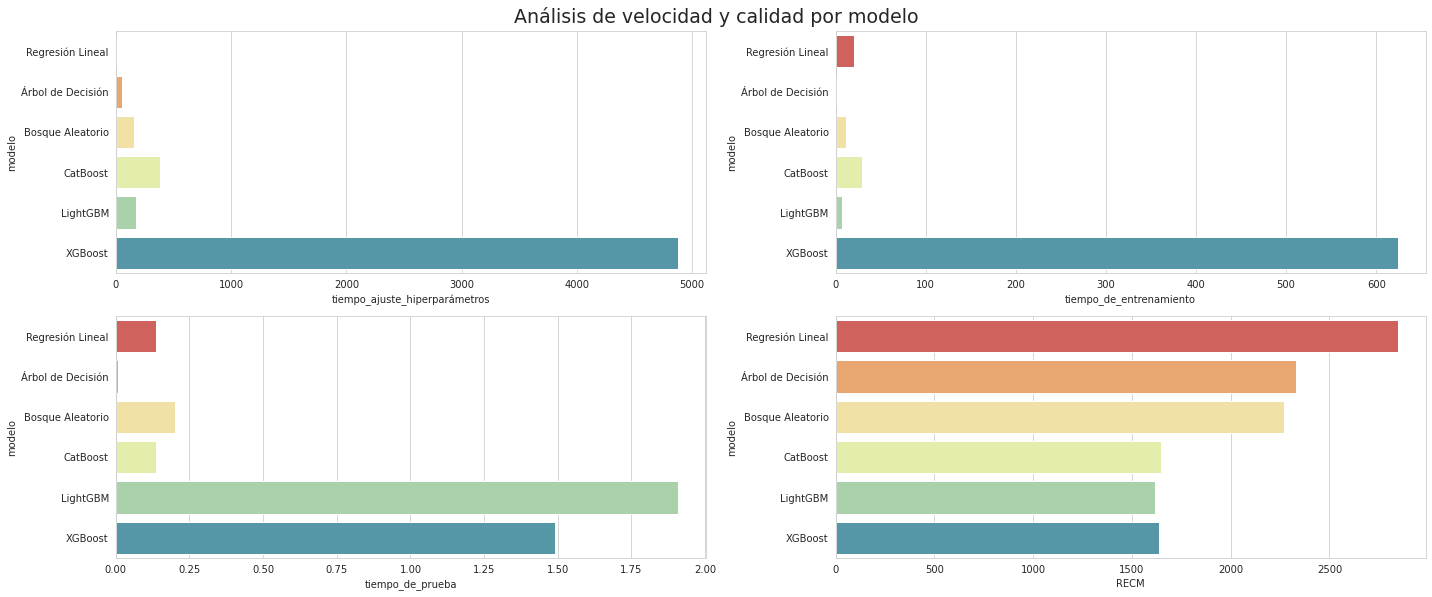

In [106]:
# traza gráficos de barras a través de subplots
fig = plt.subplots(nrows=2, ncols=2, figsize=(20, 12))

sns.set_style('whitegrid')

for n, col in enumerate(['tiempo_ajuste_hiperparámetros', 'tiempo_de_entrenamiento', 'tiempo_de_prueba', 'RECM']):
    ax = plt.subplot(3, 2, n + 1)
    sns.barplot(x=col, y='modelo', data=models_table, ax=ax, palette=("Spectral"))

plt.suptitle('Análisis de velocidad y calidad por modelo', fontsize=19)
plt.tight_layout()
plt.show()

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class=“tocSkip”></a>
¡Felicitaciones!, Es incluir esta gráfica es algo que muchos obvian pero que resulta muy útil</div>

Se estableció como prueba de cordura nuestro modelo de regresión lineal y se determinó que cualquier modelo que presentara una puntuación superior a ésta no estaría correctamente ajustado, el valor RECM base obtenido fue de 2844,635. Comparando esta puntuación con las puntuaciones que obtuvieron los cinco modelos entrenados se puede afirmar que todos ellos superaron el test de cordura, presentando un RECM inferior al valor base establecido y, en consecuencia, son mejores que la aleatorización.

En comparación con los modelos de árbol de decisión y bosque aleatorio, los métodos de boosting de gradiente presentaron los valores RECM más bajos, siendo el modelo LightGBM el que presentó la puntuación RECM más baja con 1616,837, seguido del modelo XGBoost con 1634,932 y, por último, CatBoost con 1648,352. Del mismo modo, de los tres métodos de boosting, el que obtuvo el menor tiempo de ajuste de hiperparámetros y de entrenamiento fue LightGBM, sin embargo fue el más lento a la hora de realizar predicciones. Este hecho se debe al tipo de método de división utilizado por LightGBM, que considera las instancias de datos con gradientes grandes y realiza un muestreo aleatorio para los datos con gradientes pequeños, encontrando así el punto de división óptimo y manteniendo la precisión de los árboles aprendidos, por lo que tiene un tiempo de entrenamiento más rápido.

Sin embargo, la velocidad de XGBoost fue la más lenta de todos los modelos entrenados, alcanzando 1h40m para ajustar los hiperparámetros y unos 11 minutos para entrenar el modelo. Ese comportamiento está relacionado, al igual que otros modelos boosting, con la forma de división del árbol, presentando un crecimiento del árbol a través de niveles, y además con un algoritmo que ordena las características según su importancia y luego decide la división del árbol en función de cada característica y del valor de la característica que resulta en una mayor ganancia. También debe tenerse en cuenta que este modelo no dispone de una implementación específica para procesar características categóricas, lo que hace que sea más lento cuando se utilizan técnicas de codificación como One-Hot.

Por último, el mejor método de boosting fue CatBoost, pero las diferencias entre ambos métodos no son muy significativas. Su tiempo de ajuste fue de casi seis minutos, menor que el de XGBoost aunque no tan rápido como el de LightGBM. Esto puede estar en relación con la implementación que tiene para procesar características categóricas, que a diferencia de XGBoost, no requiere un preprocesamiento, sino que el propio método realiza la codificación. Asimismo, hay que tener en cuenta que sólo se entrenó un conjunto de 100 árboles, por lo que quizás aumentando el tamaño del conjunto el valor de RECM sea menor.

## Conclusiones

**Preprocesamiento de datos**

1. El conjunto de datos en cuestión contenía ciertos problemas que exigían un tratamiento previo adecuado. Se convirtieron los nombres de las columnas a minúsculas, los valores duplicados se eliminaron y se cambió el tipo de datos de las características de fecha a tipo datetime. Se sustituyeron los valores que faltaban en función de la moda de características como el modelo, la marca o el año de matriculación del vehículo. Para los valores que no dependían de forma evidente de otras variables, se optó por construir un modelo de Regresión Logística que permitiese imputar si un coche había sido reparado o no. 

2. Para el año de matrícula, el precio, la potencia y el mes de matrícula se registraron artefactos extraños. Se decidió eliminar los valores extremos, como los vehículos matriculados en el año 9999, precios inferiores a 50 dólares o clasificaciones de potencia de hasta 20000 CV. Aquellos con potencia cercana a cero se imputaron según el modelo de vehículo, ya que al eliminarlos se perdía el 11% del conjunto de datos. Se optó finalmente por calcular la edad del vehículo a partir del año de matriculación y del año de creación del perfil, con lo que se redujo el número de características que procesará nuestro modelo. 

3. Previamente al aprendizaje del modelo se optó por eliminar determinadas características que no servirían para predecir el precio de un vehículo: date_crawled, registration_year, registration_month, date_created, postal_code, last_seen.

**Entrenamiento modelos**

4. Se han entrenado seis modelos: regresión lineal, árbol de decisión, bosque aleatorio, CatBoost, LightGBM y XGBoost. Para cada modelo se realizó un ajuste de hiperparámetros mediante GridSearchCV, y en base a los mejores hiperparámetros cada modelo fue entrenado y se realizaron predicciones. El tiempo de ajuste, entrenamiento y prueba fue medido, ya que Rusty Bargain está buscando un modelo que no sólo tenga calidad sino también velocidad. 

5. Para cada modelo se utilizaron distintos métodos de preprocesamiento de características categóricas. Para la regresión lineal y XGBoost utilizamos One-Hot Encoding, para los árboles de decisión y random forest utilizamos Ordinal Encoder label encoding, para LightGBM se optó por transformar las categorías de tipo objeto a tipo categoría, y finalmente para CatBoost se utilizó nuestro conjunto de datos final sin valores perdidos ni valores atípicos.

**Modelo de mejor calidad y velocidad**

6. El modelo más adecuado fue LightGBM con los siguientes hiperparámetros:{'learning_rate': 0.2, 'n_estimators': 300, 'num_leaves': 20}, logrando un RECM de 1616.837, un tiempo de entrenamiento de ≈9.988 segundos y una velocidad de predicción de ≈1.907 segundos. También una buena elección sería el método CatBoost gradient boosting, que pese a registrar el RECM más alto 1648, su tiempo de ajuste y de entrenamiento no era tan elevado como XGBoost, además de que tiene su propia implementación para el procesamiento de características categóricas.

# Lista de control

Escribe 'x' para verificar. Luego presiona Shift+Enter

- [x]  Jupyter Notebook está abierto
- [x]  El código no tiene errores- [X]  Las celdas con el código han sido colocadas en orden de ejecución- [X]  Los datos han sido descargados y preparados- [X]  Los modelos han sido entrenados
- [x]  Se realizó el análisis de velocidad y calidad de los modelos